In [1]:
import numpy as np
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# =========================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# =========================
# Bạn thay đổi các đường dẫn này cho đúng với file của bạn nhé
MODEL_PATH = "/kaggle/input/models/hoangkhuongduy/cdscsdc/tensorflow2/default/1/best_densenet201_v2_0.89_512.keras" # Thay bằng tên file .keras cuối cùng của bạn
JSON_PATH = "/kaggle/input/datasets/hoangkhuongduy/kkkklllll/class_indices (1).json"
IMAGE_PATH = "/kaggle/input/datasets/hoangkhuongduy/xxxxxxx/khi phe thung.jpeg" # Điền đường dẫn ảnh bạn muốn nhận diện

IMAGE_SIZE = 224

# =========================
# 2. LOAD MODEL VÀ TÊN NHÃN
# =========================
print("Đang tải mô hình...")
model = load_model(MODEL_PATH)

print("Đang tải danh sách nhãn...")
with open(JSON_PATH, "r") as f:
    class_indices = json.load(f)

# class_indices hiện đang có dạng {'COVID': 0, 'NORMAL': 1,...}
# Chúng ta cần đảo ngược lại thành {0: 'COVID', 1: 'NORMAL',...} để tra cứu từ kết quả dự đoán
labels = {v: k for k, v in class_indices.items()}

# =========================
# 3. TIỀN XỬ LÝ ẢNH
# =========================
print(f"Đang xử lý ảnh: {IMAGE_PATH}")
# Đọc ảnh và resize về đúng kích thước lúc train (224x224)
img = image.load_img(IMAGE_PATH, target_size=(IMAGE_SIZE, IMAGE_SIZE))

# Chuyển ảnh thành mảng numpy
img_array = image.img_to_array(img)

# Thêm chiều batch (từ (224, 224, 3) thành (1, 224, 224, 3)) vì Keras nhận đầu vào là một batch
img_array = np.expand_dims(img_array, axis=0)

# Chuẩn hóa giá trị pixel về [0, 1] (CỰC KỲ QUAN TRỌNG: Phải giống hệt rescale=1./255 lúc train)
img_array = img_array / 255.0

# =========================
# 4. DỰ ĐOÁN
# =========================
predictions = model.predict(img_array)

# Lấy index của class có xác suất cao nhất
predicted_class_index = np.argmax(predictions, axis=1)[0]

# Lấy độ tin cậy (xác suất) của class đó
confidence = np.max(predictions)

# Dịch từ index sang tên nhãn
predicted_label = labels[predicted_class_index]

print("\n=====================================")
print(f"Kết quả dự đoán : {predicted_label}")
print(f"Độ tin cậy      : {confidence * 100:.2f}%")
print("=====================================")

2026-06-03 02:51:15.802559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780455075.996796      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780455076.055517      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780455076.507498      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780455076.507543      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780455076.507546      57 computation_placer.cc:177] computation placer alr

Đang tải mô hình...


I0000 00:00:1780455098.483575      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780455098.489557      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Đang tải danh sách nhãn...
Đang xử lý ảnh: /kaggle/input/datasets/hoangkhuongduy/xxxxxxx/khi phe thung.jpeg


I0000 00:00:1780455111.513833     132 service.cc:152] XLA service 0x7c93ac028500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780455111.513874     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780455111.513878     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780455114.305573     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step

Kết quả dự đoán : PNEUMONIA
Độ tin cậy      : 65.42%


I0000 00:00:1780455130.251687     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Train from: /kaggle/input/datasets/hoangkhuongduy/new-data-set/Final_Data/train
Test from: /kaggle/input/datasets/hoangkhuongduy/new-data-set/Final_Data/test
Val from: /kaggle/input/datasets/hoangkhuongduy/new-data-set/Final_Data/val
Found 15638 images belonging to 5 classes.
Found 1797 images belonging to 5 classes.
Found 1836 images belonging to 5 classes.
Số class: 5
Class indices: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'Tuberculosis': 3, 'emphReform': 4}


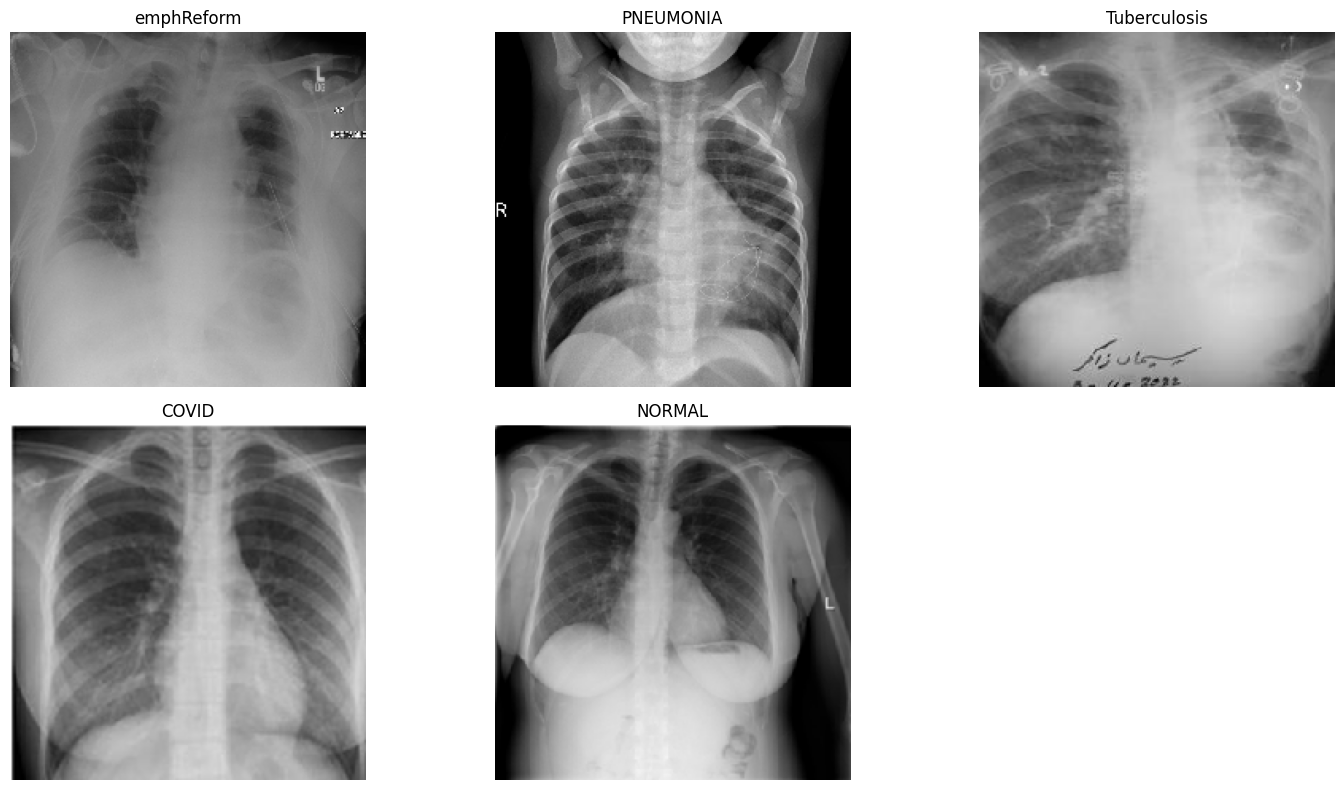

Found 15638 images belonging to 5 classes.


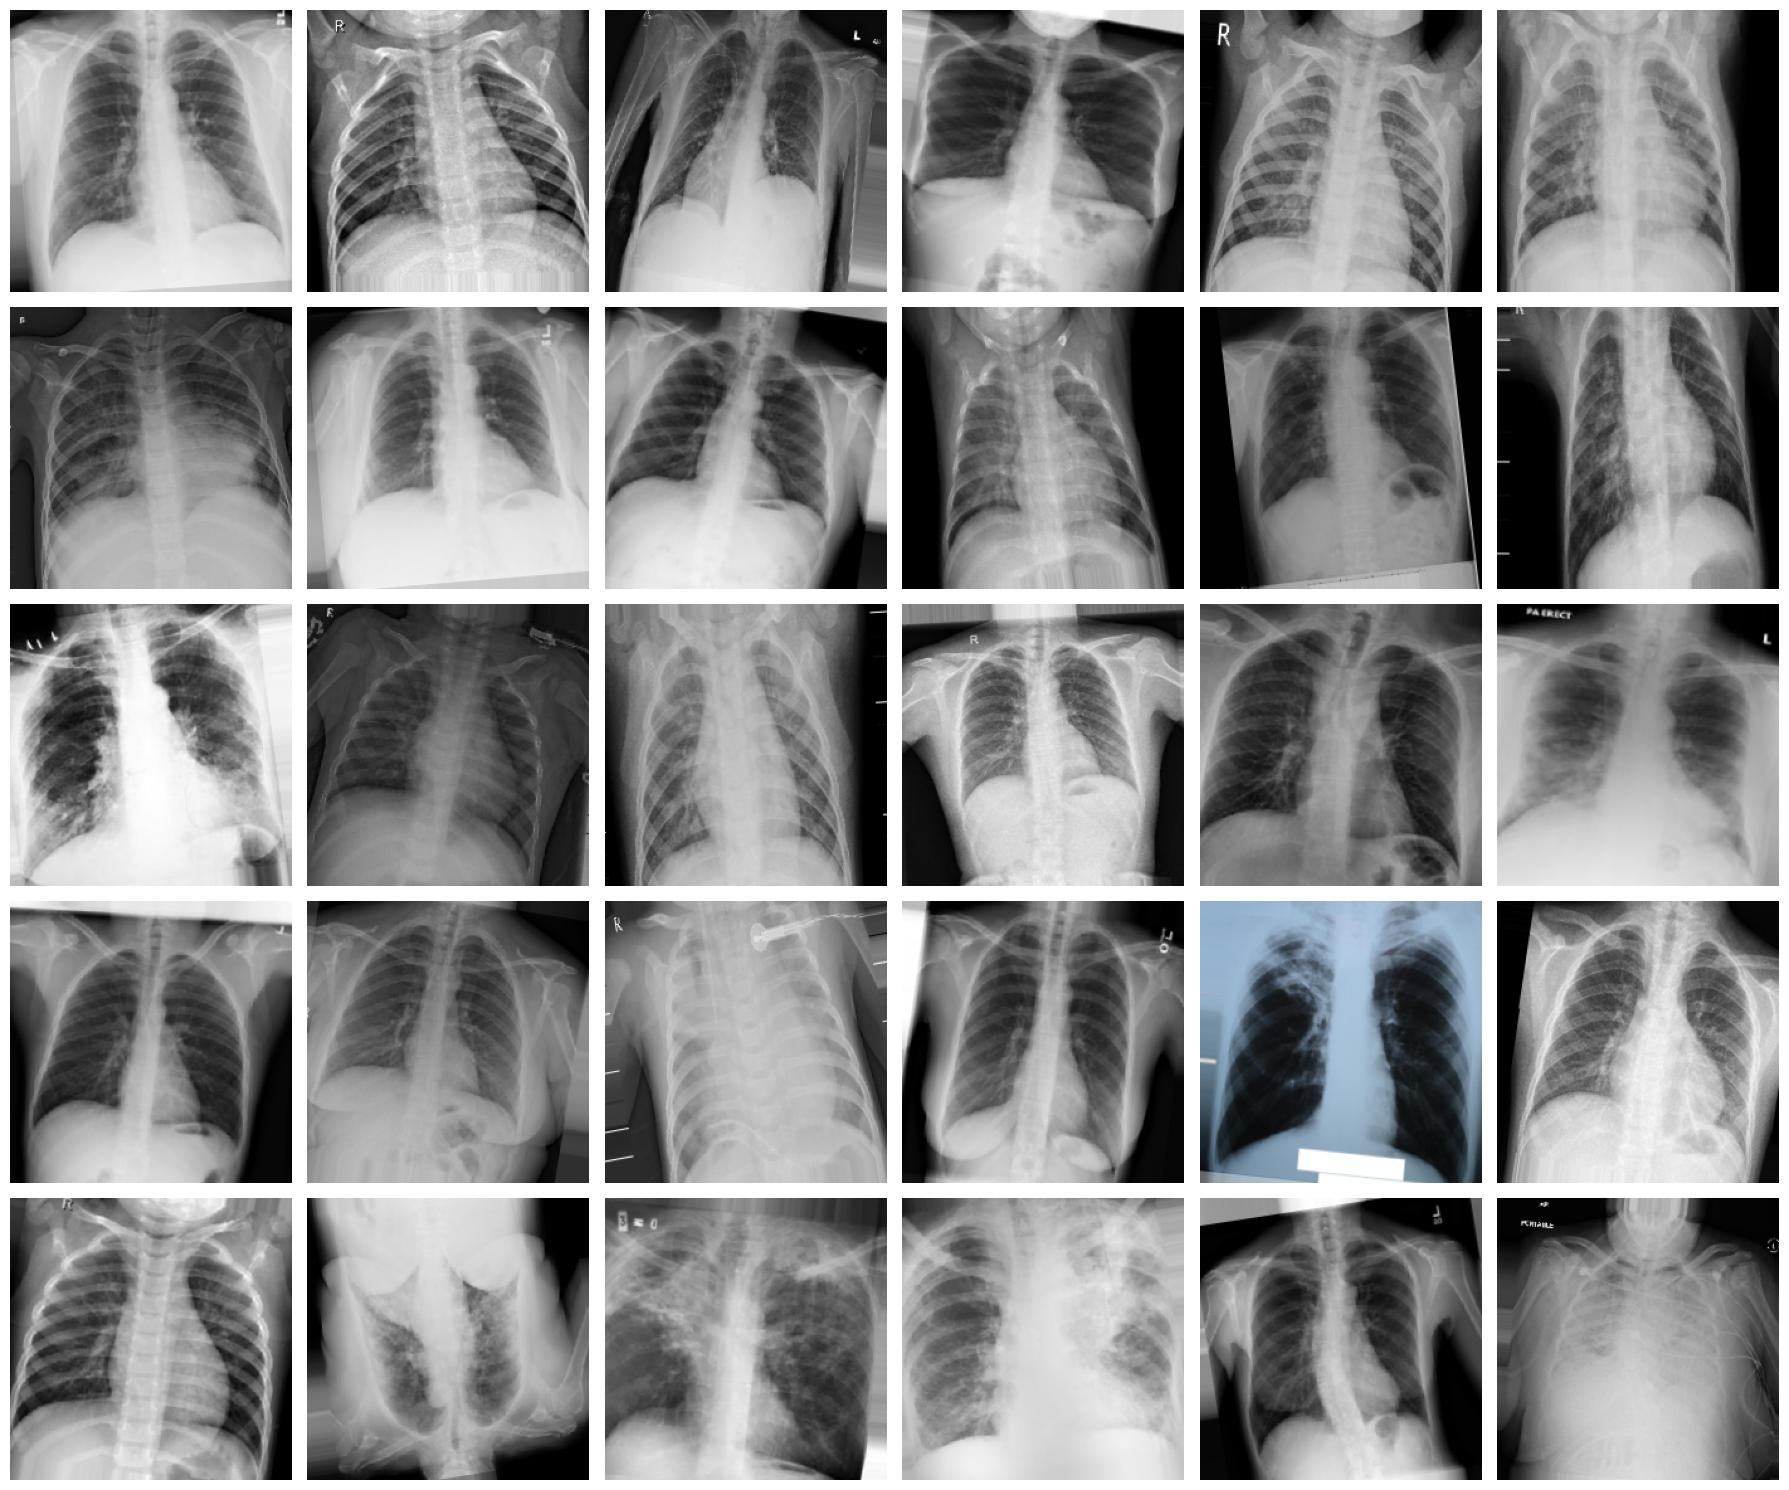

Saved image at:
/kaggle/working/augmented_preview/all_augmented_images.png
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.4266 - loss: 1.3759
Epoch 1: val_accuracy improved from -inf to 0.72176, saving model to /kaggle/working/best_densenet201_v2.keras
489/489 ━━━━━━━━━━━━━━━━━━━━ 497s 915ms/step - accuracy: 0.4268 - loss: 1.3755 - val_accuracy: 0.7218 - val_loss: 0.8984
Epoch 2/30
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.6922 - loss: 0.8658
Epoch 2: val_accuracy improved from 0.72176 to 0.77963, saving model to /kaggle/working/best_densenet201_v2.keras
489/489 ━━━━━━━━━━━━━━━━━━━━ 295s 604ms/step - accuracy: 0.6922 - loss: 0.8657 - val_accuracy: 0.7796 - val_loss: 0.6777
Epoch 3/30
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.7512 - loss: 0.7126
Epoch 3: val_accuracy improved from 0.77963 to 0.80857, saving model to /kaggle/working/best_densenet201_v2.keras
489/489 ━━━━━━━━━━━━━━━━━━━━ 291s 594ms/step - accuracy: 0.7512 - loss: 0.7125 - val_accuracy: 0.8086 - val_loss: 0.5786
Epoch 4/30
489/489 ━━━━━━━━━━━━━━━

In [2]:
import os
import time
import json
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.applications.densenet import DenseNet201
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

# =========================
# CONFIG
# =========================

path = "/kaggle/input/datasets/hoangkhuongduy/new-data-set/Final_Data"   # sửa lại đường dẫn dataset

BATCH_SIZE = 32
NB_EPOCHS = 30
IMAGE_SIZE = 224
NB_FEATURES = 512
LEARNING_RATE = 1e-5

TRAIN_DIR = os.path.join(path, "train")
TEST_DIR = os.path.join(path, "test")
VAL_DIR = os.path.join(path, "val")

OUTPUT_DIR = "/kaggle/working"
name_model = os.path.join(OUTPUT_DIR, "best_densenet201_v2")

print(tf.config.list_physical_devices("GPU"))
print("Train from:", TRAIN_DIR)
print("Test from:", TEST_DIR)
print("Val from:", VAL_DIR)

# =========================
# DATA GENERATOR
# =========================

train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

nb_samples = train_generator.samples
nb_classes = train_generator.num_classes

print("Số class:", nb_classes)
print("Class indices:", train_generator.class_indices)

# Lưu thứ tự nhãn
with open(os.path.join(OUTPUT_DIR, "class_indices.json"), "w") as f:
    json.dump(train_generator.class_indices, f)
import matplotlib.pyplot as plt
from collections import Counter

# Lấy nhãn từ generator
import matplotlib.pyplot as plt
import numpy as np

# lấy mapping class
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

found_classes = set()
images_per_class = {}

# duyệt qua generator để lấy đủ mỗi class 1 ảnh
for images, labels in train_generator:
    for i in range(len(images)):
        class_id = np.argmax(labels[i])
        
        if class_id not in found_classes:
            images_per_class[class_id] = images[i]
            found_classes.add(class_id)

        if len(found_classes) == len(class_indices):
            break
    if len(found_classes) == len(class_indices):
        break

# plot
plt.figure(figsize=(15, 8))

for i, (class_id, image) in enumerate(images_per_class.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(idx_to_class[class_id])
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# DATA AUGMENTATION
# =========================
# =========================
# DATA AUGMENTATION
# =========================
# =========================
# DATA AUGMENTATION
# =========================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    shear_range=0.05,
    horizontal_flip=False,
    fill_mode="nearest"
)

# tạo lại generator có augmentation
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

# =========================
# SAVE 30 IMAGES INTO 1 IMAGE
# =========================

import matplotlib.pyplot as plt

# thư mục lưu ảnh
augment_save_dir = "/kaggle/working/augmented_preview"
os.makedirs(augment_save_dir, exist_ok=True)

# lấy batch đầu tiên
x_batch, y_batch = next(train_generator)

# tạo figure chứa 30 ảnh
fig = plt.figure(figsize=(18, 15))

for i in range(30):

    image = x_batch[i % len(x_batch)]

    plt.subplot(5, 6, i + 1)
    plt.imshow(image)
    plt.axis("off")

# căn layout
plt.tight_layout()

# lưu toàn bộ thành 1 ảnh duy nhất
final_save_path = os.path.join(
    augment_save_dir,
    "all_augmented_images.png"
)

plt.savefig(final_save_path, dpi=300, bbox_inches="tight")

# hiển thị
plt.show()

print("Saved image at:")
print(final_save_path)
# =========================
# MODEL
# =========================

base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)
x = Dense(NB_FEATURES, activation="relu")(x)
x = Dropout(0.3)(x)

# Multi-class => softmax
predictions = Dense(nb_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

# model.summary()

# =========================
# CALLBACKS
# =========================

csv_logger = CSVLogger(name_model + "_training.log", append=False)

checkpoint = ModelCheckpoint(
    name_model + ".keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

# =========================
# TRAIN
# =========================

begin = time.time()

history = model.fit(
    train_generator,
    epochs=NB_EPOCHS,
    # steps_per_epoch=nb_samples // BATCH_SIZE,
    validation_data=val_generator,
    callbacks=[csv_logger, checkpoint],
    verbose=1
)

run_time = time.time() - begin

# =========================
# TEST / EVALUATE
# =========================

model = load_model(name_model + ".keras")

pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)
test_loss, _ = model.evaluate(
    test_generator,
    verbose=1
)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Test Loss:", test_loss)
print("Precision:", precision)
print("F1:", f1)
print("Recall:", recall)

# =========================
# SAVE RESULT
# =========================

result_path = name_model + f"_{round(accuracy, 4)}_{NB_FEATURES}_result.txt"

with open(result_path, "w") as file_result:
    file_result.write("\n-----------------------------------------------")
    file_result.write("\nFile               " + str(name_model))
    file_result.write("\n-----------------------------------------------")
    file_result.write("\nTest acc           |" + str(accuracy))
    file_result.write("\nTime               |" + str(run_time))
    file_result.write("\n-----------------------------------------------")
    file_result.write("\naccuracy_score     |" + str(accuracy))
    file_result.write("\nprecision_score    |" + str(precision))
    file_result.write("\nf1_score           |" + str(f1))
    file_result.write("\nrecall_score       |" + str(recall))

# Rename best model
final_model_path = name_model + f"_{round(accuracy, 2)}_{NB_FEATURES}.keras"
os.rename(name_model + ".keras", final_model_path)

print("Saved model:", final_model_path)
print("Saved result:", result_path)

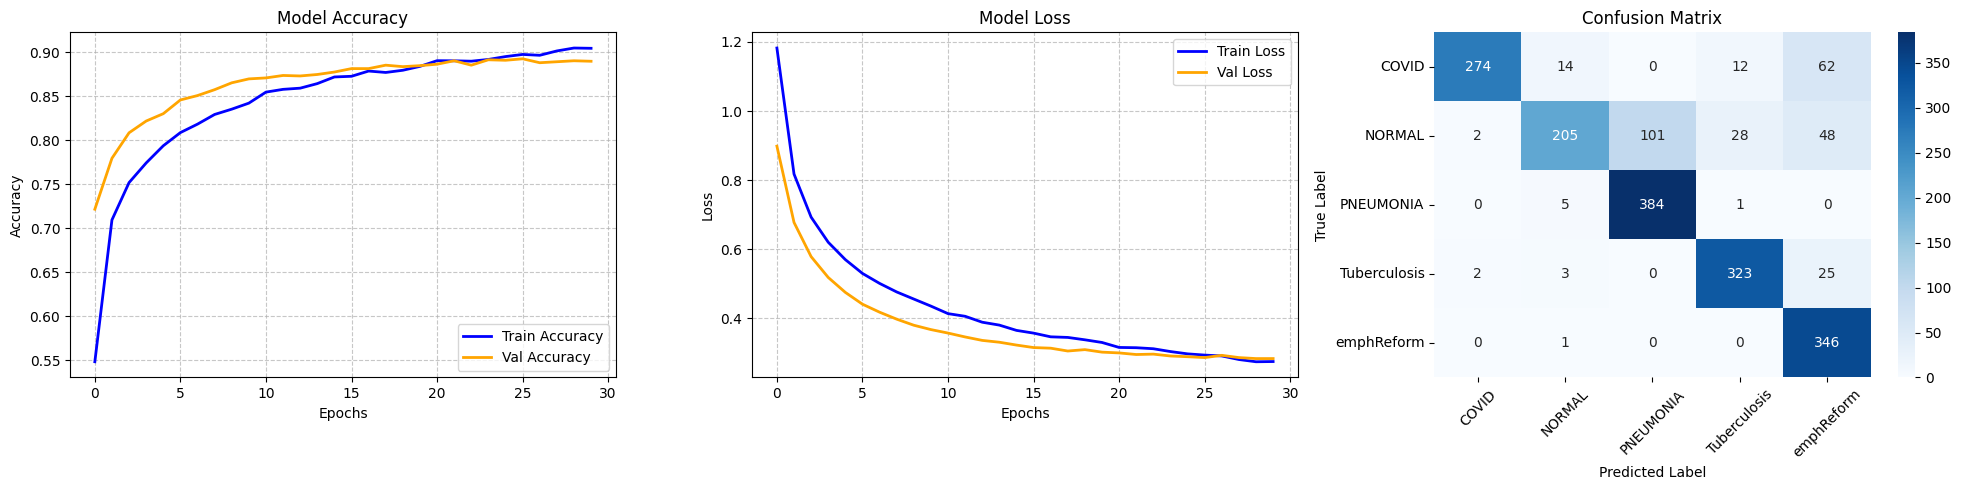

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_training_results(history, y_true, y_pred, class_indices):
    """
    Hàm vẽ biểu đồ Accuracy/Loss và Confusion Matrix.
    - history: Lấy từ biến history = model.fit(...)
    - y_true: Nhãn thực tế của tập test
    - y_pred: Nhãn dự đoán của model trên tập test
    - class_indices: Dictionary chứa tên các class (từ train_generator.class_indices)
    """
    
    # Đảo ngược class_indices từ {Tên: Code} thành {Code: Tên} để hiện thị trên trục
    class_names = [k for k, v in sorted(class_indices.items(), key=lambda item: item[1])]

    # TẠO KHUNG VẼ GỒM 3 BIỂU ĐỒ (1 Hàng x 3 Cột)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # ==========================================
    # 1. BIỂU ĐỒ ACCURACY (Độ chính xác)
    # ==========================================
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # ==========================================
    # 2. BIỂU ĐỒ LOSS (Hàm mất mát)
    # ==========================================
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # ==========================================
    # 3. MA TRẬN NHẦM LẪN (Confusion Matrix)
    # ==========================================
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                xticklabels=class_names, yticklabels=class_names)
    axes[2].set_title('Confusion Matrix')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')
    
    # Xoay chữ ở trục X để dễ đọc nếu tên class dài
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH SỬ DỤNG (Gọi hàm)
# ==========================================
# Lưu ý: Bạn cần phải có sẵn các biến history, y_true, y_pred và train_generator từ lúc train nhé!

plot_training_results(
    history=history, 
    y_true=y_true, 
    y_pred=y_pred, 
    class_indices=train_generator.class_indices
)

In [4]:
import os
import time
import json
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

# =========================
# CONFIG
# =========================

path = "/kaggle/input/datasets/hoangkhuongduy/kkkkkkkkk/Final_Data"  # sửa lại đường dẫn dataset

BATCH_SIZE = 32
NB_EPOCHS = 30
IMAGE_SIZE = 224
NB_FEATURES = 512

# THAY ĐỔI 1: Tăng Learning Rate lên 1e-4 để EfficientNet học tốt hơn
LEARNING_RATE = 1e-4 

TRAIN_DIR = os.path.join(path, "train")
TEST_DIR = os.path.join(path, "test")
VAL_DIR = os.path.join(path, "val")

OUTPUT_DIR = "/kaggle/working"
name_model = os.path.join(OUTPUT_DIR, "best_efficientnetb0_v2")

print(tf.config.list_physical_devices("GPU"))
print("Train from:", TRAIN_DIR)
print("Test from:", TEST_DIR)
print("Val from:", VAL_DIR)

# =========================
# DATA GENERATOR
# =========================

# THAY ĐỔI 2: Đã XÓA rescale=1./255 vì EfficientNet mong muốn nhận ảnh gốc [0, 255]
train_datagen = ImageDataGenerator()

val_datagen = ImageDataGenerator()

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

nb_samples = train_generator.samples
nb_classes = train_generator.num_classes

print("Số class:", nb_classes)
print("Class indices:", train_generator.class_indices)

with open(os.path.join(OUTPUT_DIR, "class_indices.json"), "w") as f:
    json.dump(train_generator.class_indices, f)

# =========================
# MODEL
# =========================

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)
x = Dense(NB_FEATURES, activation="relu")(x)
x = Dropout(0.3)(x)

# Multi-class => softmax
predictions = Dense(nb_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

# model.summary()

# =========================
# CALLBACKS
# =========================

csv_logger = CSVLogger(name_model + "_training.log", append=False)

checkpoint = ModelCheckpoint(
    name_model + ".keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

# =========================
# TRAIN
# =========================

begin = time.time()

history = model.fit(
    train_generator,
    epochs=NB_EPOCHS,
    # steps_per_epoch=nb_samples // BATCH_SIZE, # Đã comment để Keras tự tính số bước chuẩn
    validation_data=val_generator,
    callbacks=[csv_logger, checkpoint],
    verbose=1
)

run_time = time.time() - begin

# =========================
# TEST
# =========================

model = load_model(name_model + ".keras")

pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)
test_loss, _ = model.evaluate(
    test_generator,
    verbose=1
)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Test Loss:", test_loss)
print("Precision:", precision)
print("F1:", f1)
print("Recall:", recall)

# =========================
# SAVE RESULT
# =========================

result_path = name_model + f"_{round(accuracy, 4)}_{NB_FEATURES}_result.txt"

with open(result_path, "w") as file_result:
    file_result.write("\n-----------------------------------------------")
    file_result.write("\nFile               " + str(name_model))
    file_result.write("\n-----------------------------------------------")
    file_result.write("\nTest acc           |" + str(accuracy))
    file_result.write("\nTime               |" + str(run_time))
    file_result.write("\n-----------------------------------------------")
    file_result.write("\naccuracy_score     |" + str(accuracy))
    file_result.write("\nprecision_score    |" + str(precision))
    file_result.write("\nf1_score           |" + str(f1))
    file_result.write("\nrecall_score       |" + str(recall))

final_model_path = name_model + f"_{round(accuracy, 2)}_{NB_FEATURES}.keras"
os.rename(name_model + ".keras", final_model_path)

print("Saved model:", final_model_path)
print("Saved result:", result_path)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Train from: /kaggle/input/datasets/hoangkhuongduy/kkkkkkkkk/Final_Data/train
Test from: /kaggle/input/datasets/hoangkhuongduy/kkkkkkkkk/Final_Data/test
Val from: /kaggle/input/datasets/hoangkhuongduy/kkkkkkkkk/Final_Data/val
Found 15556 images belonging to 5 classes.
Found 1797 images belonging to 5 classes.
Found 1836 images belonging to 5 classes.
Số class: 5
Class indices: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'Tuberculosis': 3, 'emphReform': 4}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


2026-06-03 05:25:17.657507: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:25:17.800874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:25:18.157192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:25:18.299107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:25:19.146309: E external/local_xla/xla/stream_

 60/487 ━━━━━━━━━━━━━━━━━━━━ 2:58 418ms/step - accuracy: 0.4443 - loss: 1.3487

...

487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.7132 - loss: 0.7867

2026-06-03 05:29:44.580627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:29:44.716160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:29:45.031620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:29:45.172445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 05:29:45.937282: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.92376, saving model to /kaggle/working/best_efficientnetb0_v2.keras
487/487 ━━━━━━━━━━━━━━━━━━━━ 292s 543ms/step - accuracy: 0.7135 - loss: 0.7861 - val_accuracy: 0.9238 - val_loss: 0.2526
Epoch 2/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9031 - loss: 0.2827
Epoch 2: val_accuracy improved from 0.92376 to 0.94992, saving model to /kaggle/working/best_efficientnetb0_v2.keras
487/487 ━━━━━━━━━━━━━━━━━━━━ 147s 301ms/step - accuracy: 0.9031 - loss: 0.2826 - val_accuracy: 0.9499 - val_loss: 0.1689
Epoch 3/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9320 - loss: 0.2082
Epoch 3: val_accuracy improved from 0.94992 to 0.96160, saving model to /kaggle/working/best_efficientnetb0_v2.keras
487/487 ━━━━━━━━━━━━━━━━━━━━ 146s 300ms/step - accuracy: 0.9320 - loss: 0.2082 - val_accuracy: 0.9616 - val_loss: 0.1366
Epoch 4/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9410 - loss: 0.1768
Epoch 4: val_accuracy im

2026-06-03 06:41:59.817787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 06:41:59.956067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 06:42:00.275197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 06:42:00.416510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 06:42:01.187956: E external/local_xla/xla/stream_

58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 683ms/step
58/58 ━━━━━━━━━━━━━━━━━━━━ 28s 349ms/step - accuracy: 0.8837 - loss: 0.3889
Accuracy: 0.9172113289760349
Test Loss: 0.28227829933166504
Precision: 0.9273798825337568
F1: 0.914211071565738
Recall: 0.9172113289760349
Saved model: /kaggle/working/best_efficientnetb0_v2_0.92_512.keras
Saved result: /kaggle/working/best_efficientnetb0_v2_0.9172_512_result.txt


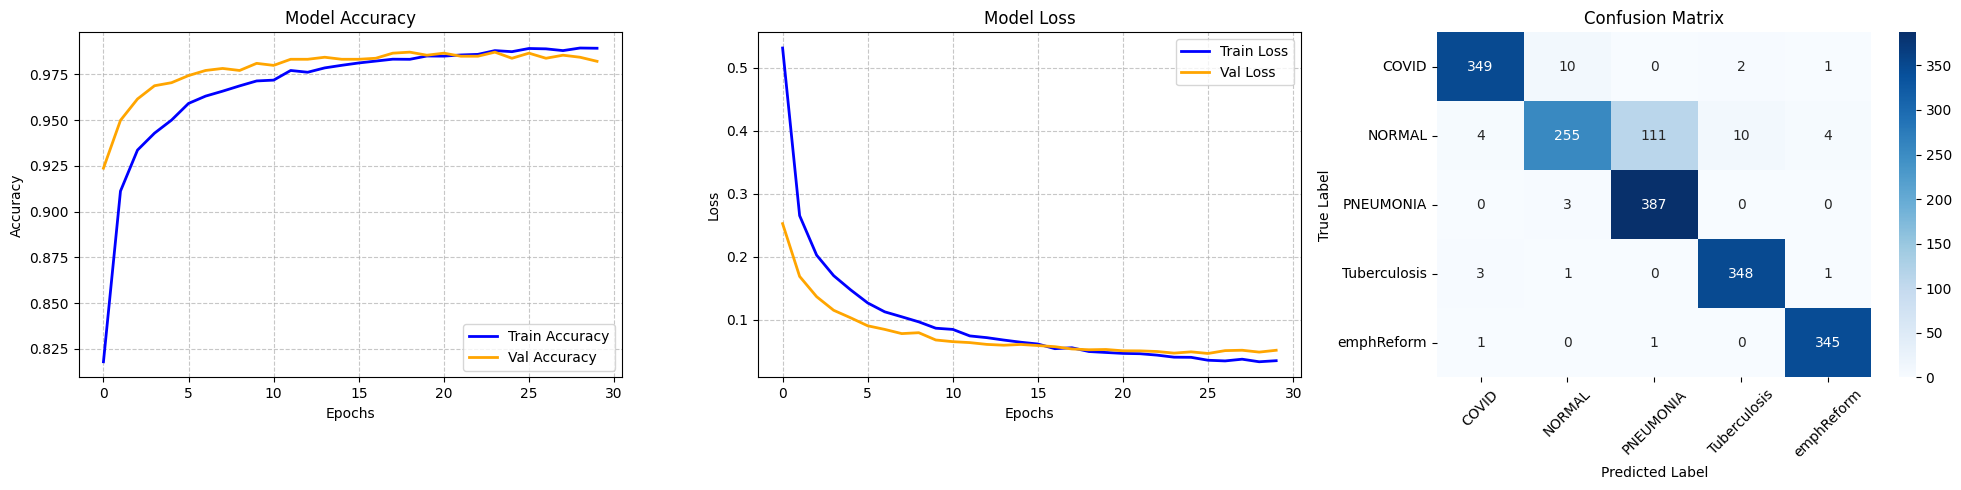

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_training_results(history, y_true, y_pred, class_indices):
    """
    Hàm vẽ biểu đồ Accuracy/Loss và Confusion Matrix.
    - history: Lấy từ biến history = model.fit(...)
    - y_true: Nhãn thực tế của tập test
    - y_pred: Nhãn dự đoán của model trên tập test
    - class_indices: Dictionary chứa tên các class (từ train_generator.class_indices)
    """
    
    # Đảo ngược class_indices từ {Tên: Code} thành {Code: Tên} để hiện thị trên trục
    class_names = [k for k, v in sorted(class_indices.items(), key=lambda item: item[1])]

    # TẠO KHUNG VẼ GỒM 3 BIỂU ĐỒ (1 Hàng x 3 Cột)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # ==========================================
    # 1. BIỂU ĐỒ ACCURACY (Độ chính xác)
    # ==========================================
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # ==========================================
    # 2. BIỂU ĐỒ LOSS (Hàm mất mát)
    # ==========================================
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # ==========================================
    # 3. MA TRẬN NHẦM LẪN (Confusion Matrix)
    # ==========================================
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                xticklabels=class_names, yticklabels=class_names)
    axes[2].set_title('Confusion Matrix')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')
    
    # Xoay chữ ở trục X để dễ đọc nếu tên class dài
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH SỬ DỤNG (Gọi hàm)
# ==========================================
# Lưu ý: Bạn cần phải có sẵn các biến history, y_true, y_pred và train_generator từ lúc train nhé!

plot_training_results(
    history=history, 
    y_true=y_true, 
    y_pred=y_pred, 
    class_indices=train_generator.class_indices
)

In [6]:
import numpy as np
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# =========================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# =========================
MODEL_PATH = "/kaggle/working/best_efficientnetb0_v2_0.91_512.keras" # Thay bằng tên file thực tế của bạn
JSON_PATH = "/kaggle/working/class_indices.json"
IMAGE_PATH = "/kaggle/input/datasets/hoangkhuongduy/dedwedwedwedwedewd/hinh_anh_x_quang_cua_lao_phoi_1_f4d4e67caf.jpg" 

IMAGE_SIZE = 224

# =========================
# 2. LOAD MODEL VÀ TÊN NHÃN
# =========================
print("Đang tải mô hình...")
model = load_model(MODEL_PATH)

print("Đang tải danh sách nhãn...")
with open(JSON_PATH, "r") as f:
    class_indices = json.load(f)

# Đảo ngược lại thành {0: 'COVID', 1: 'NORMAL',...}
labels = {v: k for k, v in class_indices.items()}

# =========================
# 3. TIỀN XỬ LÝ ẢNH (CHUẨN EFFICIENTNET)
# =========================
print(f"Đang xử lý ảnh: {IMAGE_PATH}")
# Đọc ảnh và resize về đúng kích thước lúc train (224x224)
img = image.load_img(IMAGE_PATH, target_size=(IMAGE_SIZE, IMAGE_SIZE))

# Chuyển ảnh thành mảng numpy
img_array = image.img_to_array(img)

# Thêm chiều batch (từ (224, 224, 3) thành (1, 224, 224, 3))
img_array = np.expand_dims(img_array, axis=0)

# LƯU Ý QUAN TRỌNG: 
# Đã XÓA dòng `img_array = img_array / 255.0`
# Vì EfficientNet đã tích hợp sẵn lớp chuẩn hóa bên trong mô hình nên cần nhận ảnh gốc [0, 255].

# =========================
# 4. DỰ ĐOÁN
# =========================
predictions = model.predict(img_array)

# Lấy index của class có xác suất cao nhất
predicted_class_index = np.argmax(predictions, axis=1)[0]

# Lấy độ tin cậy (xác suất) của class đó
confidence = np.max(predictions)

# Dịch từ index sang tên nhãn
predicted_label = labels[predicted_class_index]

print("\n=====================================")
print(f"Kết quả dự đoán : {predicted_label}")
print(f"Độ tin cậy      : {confidence * 100:.2f}%")
print("=====================================")

Đang tải mô hình...


ValueError: File not found: filepath=/kaggle/working/best_efficientnetb0_v2_0.91_512.keras. Please ensure the file is an accessible `.keras` zip file.